# Pyderivatives 4.0 Demo: The effect of April 1st China trade war on energy assets

This notebook gives a tutorial on using Pyderivatives 3.0 for option analysis and visualization. We will be studying the effect of Chinese tarrif scare in 2025 April on the energy sector, by looking at options on State Street Energy Select Sector (XLE) which is a large energy etf. This tutorial is designed to be comprehensive and will include:

- Installing Pyderatives with (simple just pip install)
- --pip install git+https://github.com/Julian-Beatty/Pyderivatives.git
- Loading option data (optionmetrics)
- Building yield curves from federal reserves data
- Data precleaning and arbitrage removal
- Calibration of Two factor Heston Model with double exponential jumps
- Plotting capabilities: Call/IV/RND/Delta-skew surfaces and panels


In [ ]:
import warnings
%pip install git+https://github.com/Julian-Beatty/Pyderivatives.git
from pyderivatives import*
import matplotlib.dates as mdates

In [2]:
import zipfile
import io
import requests
import shutil
from pathlib import Path

# URL to the repo zip
zip_url = "https://github.com/Julian-Beatty/Pyderivatives/archive/refs/heads/main.zip"

# Download zip into memory
r = requests.get(zip_url)
r.raise_for_status()

# Extract zip
with zipfile.ZipFile(io.BytesIO(r.content)) as z:
    z.extractall("_tmp_pyderivatives")

# Paths
src = Path("_tmp_pyderivatives/Pyderivatives-main/demodata")
dst = Path.cwd()

# Copy demodata into working directory
shutil.copytree(src, dst, dirs_exist_ok=True)

# Cleanup
shutil.rmtree("_tmp_pyderivatives")

print(f"demodata copied to: {dst.resolve()}")


demodata copied to: C:\Users\beatt


## Yield Curve Models

`Pyderivatives` supports multiple parametric yield curve frameworks commonly used in fixed income and derivatives applications:

- **Nelson–Siegel**
- **Svensson**
- **Rezende (2011) five-factor model**

These models can be used to construct smooth term structures for discounting, forward rate extraction, and option pricing applications. Users may choose the specification that best fits their data frequency and maturity coverage.


In [3]:
##Build Yield Curve
files=["daily-treasury-rates (1).csv",
"par-yield-curve-rates-1990-2022.csv",
"daily-treasury-rates (3).csv",
"daily-treasury-rates (2).csv"]

df=build_yield_dataframe(files)
rc_object=create_yield_curve(df)
rez_nsurface=rc_object.fit("rezende_2011",grid_days=[1,365*5],fit_days_window=[1,365*5])




C:\Users\beatt\anaconda3\Lib\site-packages\pyderivatives\yieldcurve\build_yield_curve.py:83: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  out["Date"] = pd.to_datetime(df[date_col], errors="coerce")


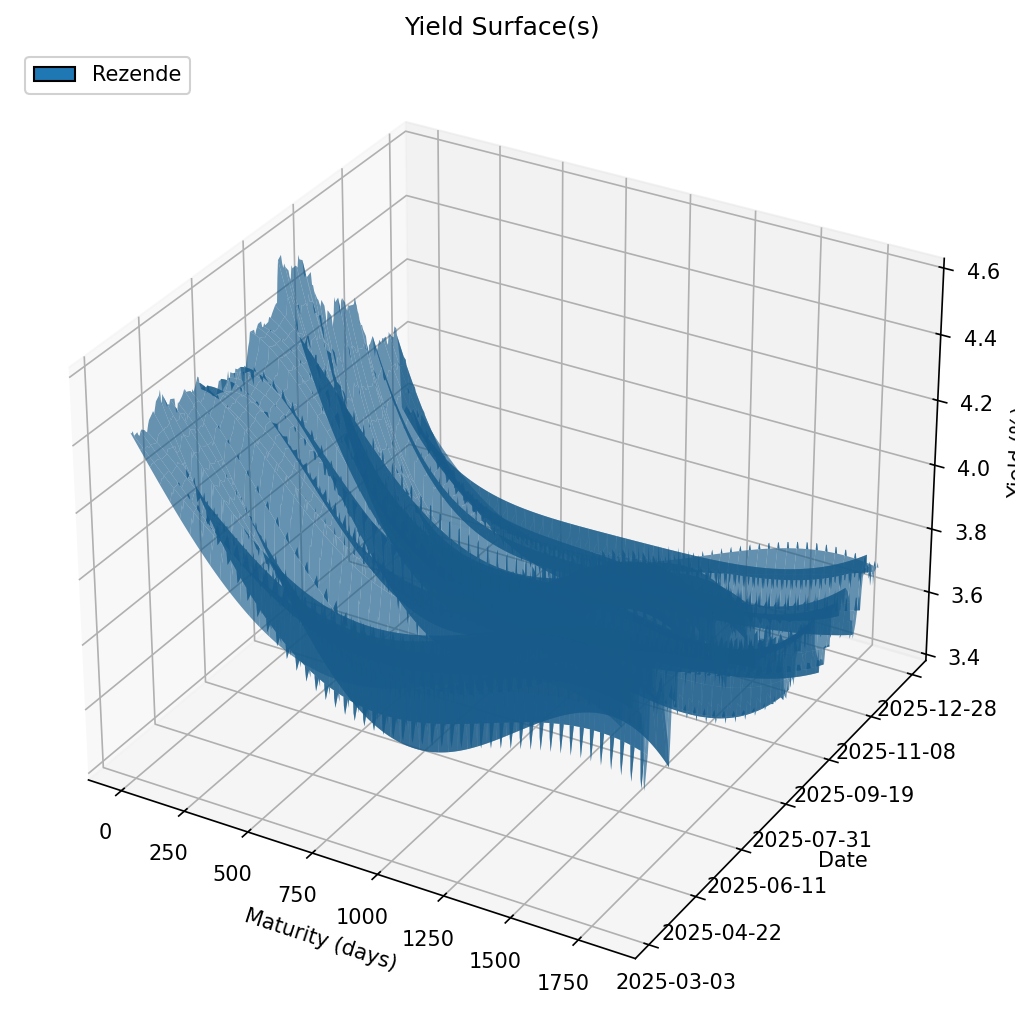

In [4]:
yield_dict={"Rezende":rez_nsurface}
fig=plot_yield_surface(yield_dict)


## Initialize the Option Market Class

Next, we initialize the **Option Market** class, which is a core building block of `pyderivatives`.

It requires the following inputs:

- **Option data** (`.csv`)
- **Yield curve** (`DataFrame`)
- **Stock data** (`.csv`)


In [5]:
###
option_market_class=OptionMarketStandardizer(option_data_filename_prefix="mini_xle_options.csv",stock_data_filename="XLE_stock.csv",
                         rate_curve_df=rez_nsurface, 
                         vendor_name="optionmetrics",
                         stock_date_col="date",
                         stock_price_col="price",
                         rate_date_col="Date")



## Market Context

The steep drop in the stock price observed in early April was largely driven by heightened concerns surrounding the U.S.–China trade war. In the following analysis, we examine how option markets reacted to this episode, with particular attention to changes in implied distributions and downside risk pricing.


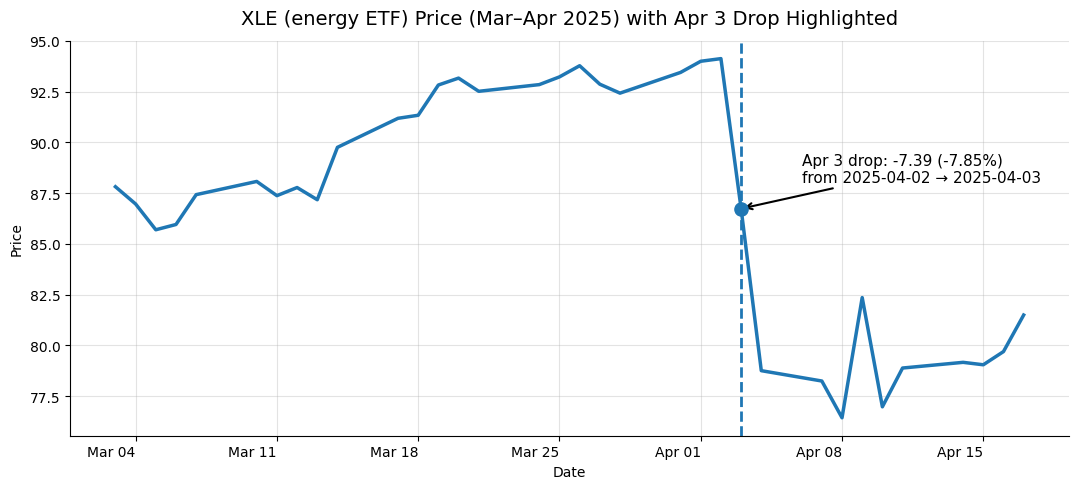

In [6]:
T_grid=np.arange(7,61)/365 #Evalute the surface each day from day 7 to 2 months.
stock_df=option_market_class.stock_raw
stock_df = stock_df.copy()
stock_df["date"] = pd.to_datetime(stock_df["date"])
stock_df = stock_df.sort_values("date")

# --- filter window ---
start, end = pd.Timestamp("2025-03-01"), pd.Timestamp("2025-04-20")
mask = (stock_df["date"] > start) & (stock_df["date"] < end)
dfw = stock_df.loc[mask, ["date", "price"]].dropna()

# --- event date to emphasize ---
event_date = pd.Timestamp("2025-04-03")

# if you don't have that exact date (weekend/holiday), pick nearest within window
if not (dfw["date"] == event_date).any():
    idx_near = (dfw["date"] - event_date).abs().idxmin()
    event_date = dfw.loc[idx_near, "date"]

event_price = float(dfw.loc[dfw["date"] == event_date, "price"].iloc[0])

# compute drop from previous available trading day in filtered window
dfw_idx = dfw.set_index("date")
prev_dates = dfw_idx.index[dfw_idx.index < event_date]
prev_price = float(dfw_idx.loc[prev_dates.max(), "price"]) if len(prev_dates) else np.nan
drop = event_price - prev_price if np.isfinite(prev_price) else np.nan
drop_pct = (drop / prev_price * 100.0) if np.isfinite(prev_price) and prev_price != 0 else np.nan

# --- pretty plot ---
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(dfw["date"], dfw["price"], linewidth=2.5)

# vertical line + marker for event
ax.axvline(event_date, linewidth=2.0, linestyle="--")
ax.scatter([event_date], [event_price], s=90, zorder=5)

# annotation text
if np.isfinite(drop):
    txt = f"Apr 3 drop: {drop:+.2f} ({drop_pct:+.2f}%)\nfrom {prev_dates.max().date()} → {event_date.date()}"
else:
    txt = f"Event: {event_date.date()}"

# place annotation slightly above the point
ymin, ymax = ax.get_ylim()
ax.annotate(
    txt,
    xy=(event_date, event_price),
    xytext=(event_date + pd.Timedelta(days=3), event_price + 0.06*(ymax - ymin)),
    arrowprops=dict(arrowstyle="->", lw=1.5),
    fontsize=11,
    ha="left",
    va="bottom",
)

# title + labels
ax.set_title("XLE (energy ETF) Price (Mar–Apr 2025) with Apr 3 Drop Highlighted", fontsize=14, pad=12)
ax.set_xlabel("Date")
ax.set_ylabel("Price")

# nice date ticks
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
fig.autofmt_xdate(rotation=0)

# subtle grid + clean spines
ax.grid(True, linewidth=0.8, alpha=0.35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

## Pre-Processing

Before calibrating the model, we perform several standard pre-processing steps to ensure data quality and internal consistency.

Specifically, we:

- Filter out **illiquid option quotes**
- Remove quotes with **maturities shorter than one week** or **longer than two months**
- Exclude quotes with **moneyness outside the range [0.8, 1.2]**
- Replace **in-the-money (ITM) call options** with their corresponding **out-of-the-money (OTM) put options** using put–call parity

After these filters are applied, we run an **arbitrage repair procedure** (following Cohen, 2020) to remove any remaining violations of static arbitrage constraints. Removing anomolies before calibration will increase robustness.


In [7]:
otm_calls = option_market_class.keep_options(
    maturity_filter=[7, 60],
    moneyness_filter=[1, 1.2],
    min_volume_filter=0.0,
    min_price_filter=0.05,
    option_right_filter="c",
)

otm_puts = option_market_class.keep_options(
    maturity_filter=[7, 60],
    moneyness_filter=[0.8, 0.99],
    min_volume_filter=0.0,
    min_price_filter=0.05,
    option_right_filter="p",
)
otm_puts_tocalls=put_call_parity(otm_puts)

OTM_options_only_df=pd.concat([otm_calls,otm_puts_tocalls]).sort_values(["date","exdate","strike"])
date_list=list(OTM_options_only_df["date"].unique())


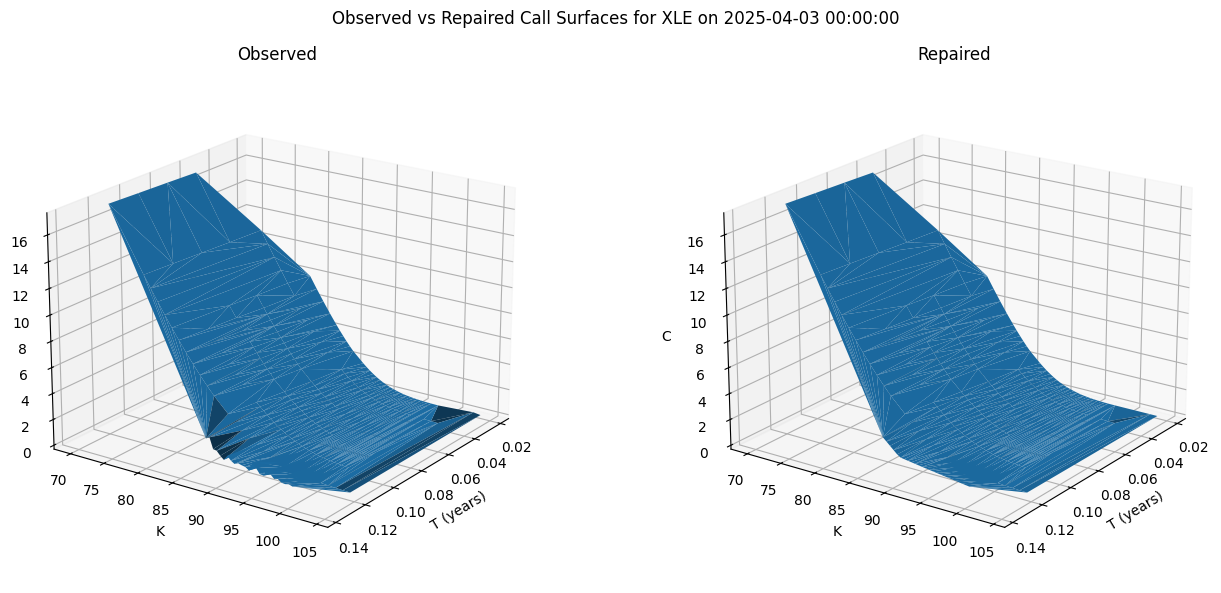

In [8]:
###Remove arbitrage before calibration. Plot repaired surface 
##Select options on one specific day
option_day_df=OTM_options_only_df[OTM_options_only_df["date"]==date_list[2]]
readable_date = pd.to_datetime(date_list[2]).strftime("%Y_%m_%d")
out = CallSurfaceArbRepair(RepairConfig()).repair_one_date(option_day_df)
pdict = out["plot_data"]
repaired_df=out["df_rep"]
fg=plot_surface(pdict,title=f"Observed vs Repaired Call Surfaces for XLE on {date_list[2]}")


In [9]:
###Optional(Setting high quality IV)
iv_cfg = IVConfig(
        sigma_init=0.3,         # starting guess for Newton
        sigma_lo=1e-8,          # lower bracket / floor
        sigma_hi=5.0,           # upper bracket (increase if you get "no root" for deep OTM)
        newton_max_iter=200,     # Newton iterations before fallback
        newton_tol=1e-8,        # convergence tolerance
        vega_floor=1e-8,       # treat vega below this as numerically unreliable
        brent_maxiter=200,      # if Newton fails, Brent iterations
        time_value_floor=1e-8,  # guards: if call time value too tiny, skip/return near 0 IV
        reject_low_vega=1e-8,   # optionally reject points with too-small vega
    )

## Model: Two-Factor Stochastic Volatility with Double-Exponential Jumps

We use a **two-factor stochastic volatility model with double-exponential jumps**. This flexible (and relatively recent) parametric specification is well-suited for fitting option surfaces with pronounced **skew** and **asymmetry**, since it combines (i) multiple volatility factors to capture term-structure dynamics and (ii) asymmetric jump behavior to capture crash risk and fat tails.

### Risk-Neutral Dynamics

Let \(S_t\) denote the asset price under the risk-neutral measure \( \mathbb{Q} \). We model log-returns with stochastic volatility and jumps:

$$
\frac{dS_t}{S_t}
= (r_t - q_t)\,dt
+ \sqrt{v_{1,t}}\,dW^{(S)}_{1,t}
+ \sqrt{v_{2,t}}\,dW^{(S)}_{2,t}
+ (e^{Y}-1)\,dN_t,
$$

where \(r_t\) is the risk-free rate, \(q_t\) is the dividend yield, and \(N_t\) is a Poisson jump process with intensity \( \lambda \).

The volatility factors follow mean-reverting square-root (CIR/Heston-type) processes:

$$
dv_{i,t} = \kappa_i(\theta_i - v_{i,t})\,dt + \sigma_i\sqrt{v_{i,t}}\,dW^{(v)}_{i,t},
\qquad i \in \{1,2\},
$$

with instantaneous correlations (typically allowing leverage effects):

$$
\mathrm{corr}\!\left(dW^{(S)}_{i,t}, dW^{(v)}_{i,t}\right)=\rho_i,
\qquad i \in \{1,2\}.
$$

### Double-Exponential Jump Sizes

Jump sizes \(Y\) are modeled using a **double-exponential** distribution (Kou-type), allowing for asymmetric left and right tails:

$$
f_Y(y)
= p\,\eta_+ e^{-\eta_+ y}\mathbf{1}_{\{y\ge 0\}}
+ (1-p)\,\eta_- e^{\eta_- y}\mathbf{1}_{\{y< 0\}},
$$

where \(p \in (0,1)\), \(\eta_+>0\), and \(\eta_->0\). This specification can generate strong downside skew (large negative jumps) while still permitting occasional large positive jumps.

In the next section, we calibrate the model parameters to the cleaned option surface and analyze how implied tail risk shifts around the early-April event window.


In [10]:
%%capture
result_dict={}
date_list=list(OTM_options_only_df["date"].unique())
for date in date_list:
    
    option_day_df=OTM_options_only_df[OTM_options_only_df["date"]==date]
    readable_date = pd.to_datetime(date).strftime("%Y_%m_%d")
    
    ###Arbitrage Repair
    out = CallSurfaceArbRepair(RepairConfig()).repair_one_date(option_day_df)
    pdict = out["plot_data"]
    repaired_df=out["df_rep"]
    
    ######## Prepare for calibration
    day=make_day_from_df(repaired_df,price_col="C_rep")


    ###### Select model and enter bounds
    pr = GlobalSurfacePricer("heston_kou_2f",Umax=1000.0, n_quad=1000)
    pr.fit(day)
    T_grid=np.arange(7,61)/365 #Evalute the surface each day from day 7 to 2 months.
    ###Price options
    results = pr.price(day,grid_mode="moneyness", m_bounds=(0.6, 1.4),m_grid_n=300, T_grid=T_grid,iv_cfg=iv_cfg,
                     compute_moments=True,compute_iv=True,compute_rnd=True,compute_delta=True,compute_cdf=True)
    
    fig=panels.call_panels(results,day=day,n_panels=5,title=f"Observed vs fitted {readable_date}")
    result_data={"day":day,"results":results}             
    ###Plot Option data
    result_dict[date]=result_data

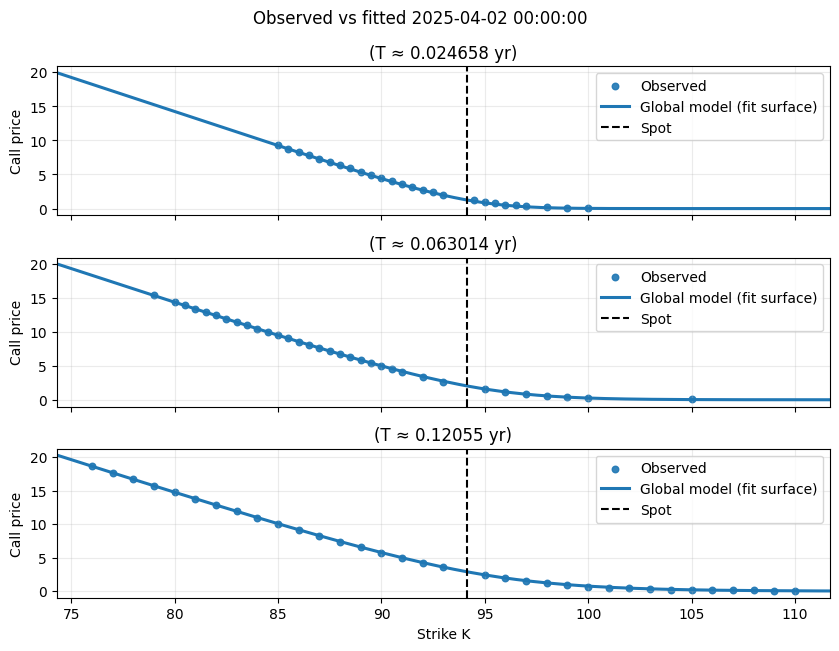

In [11]:
fig=panels.call_panels(result_dict[date_list[1]]["results"],day=result_dict[date_list[1]]["day"],n_panels=3,title=f"Observed vs fitted {date_list[1]}")

## Model Fit and Implied Densities

The calibrated model provides a good fit to observed call option prices across maturities and strikes. Having established pricing accuracy, we now turn to the sequence of **risk-neutral density (RND) panels** in the days leading up to the crash.

As the event approaches, the option-implied RNDs exhibit increasingly pronounced **negative skewness** and elevated **kurtosis**, reflecting a sharp rise in perceived downside risk and tail uncertainty. During the crash period itself, the left tail thickens substantially, indicating a heightened market-implied probability of extreme negative returns.


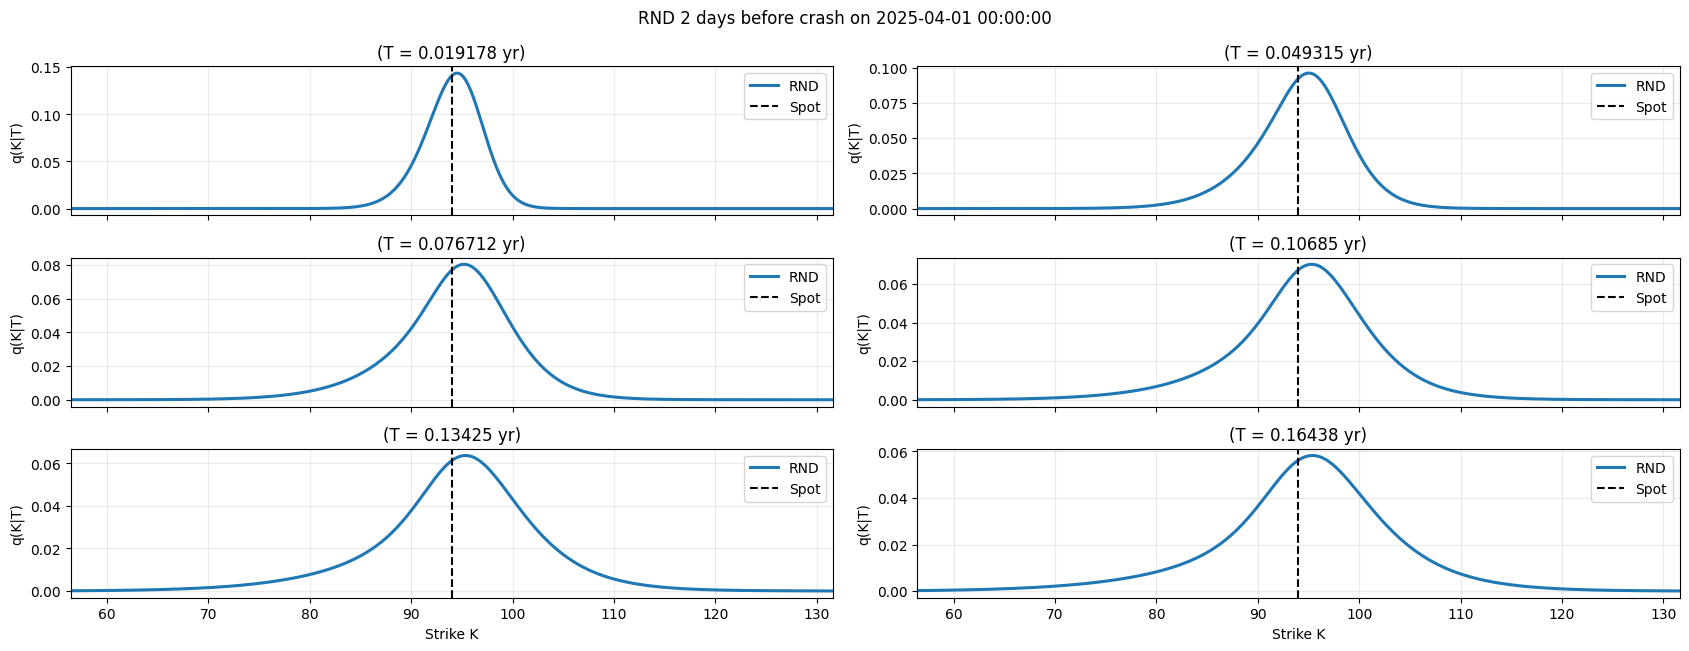

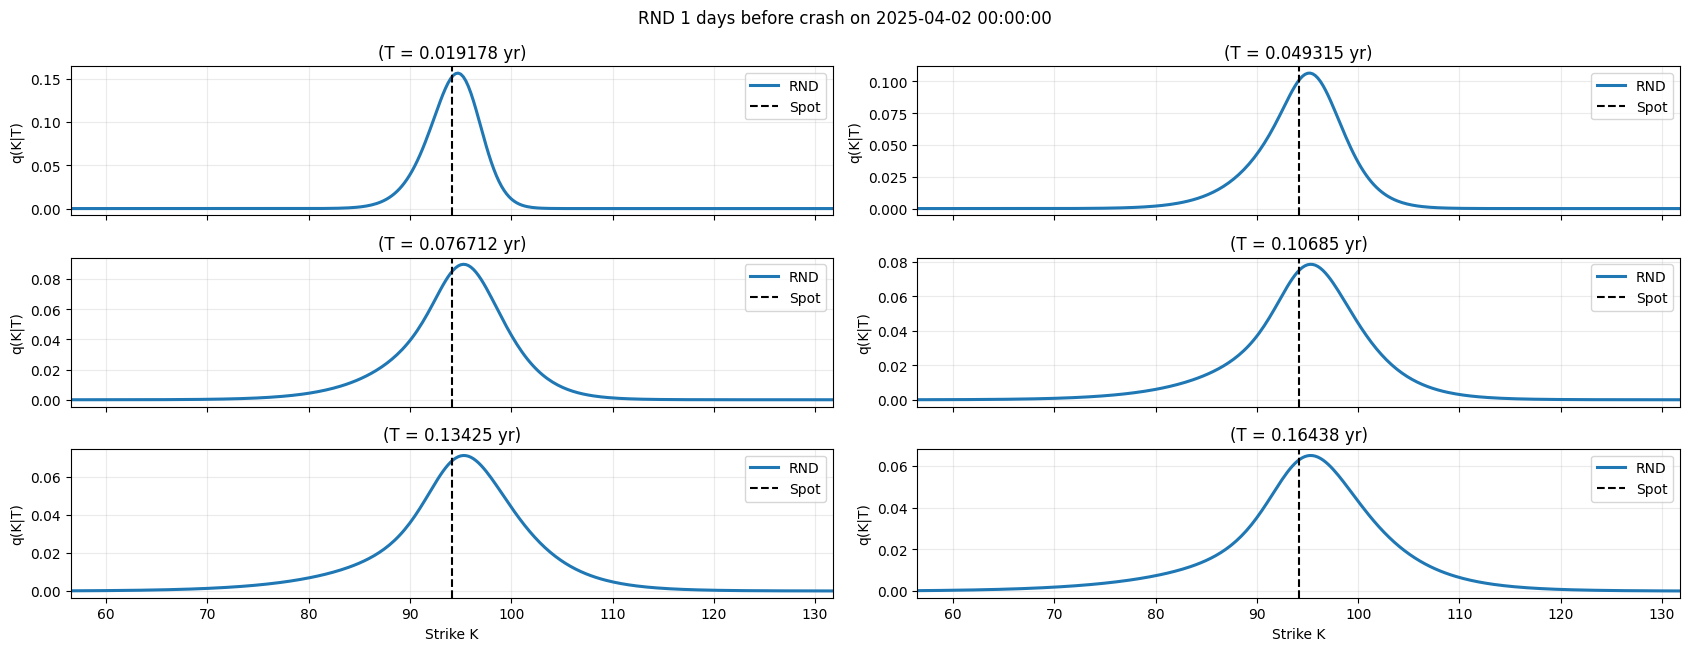

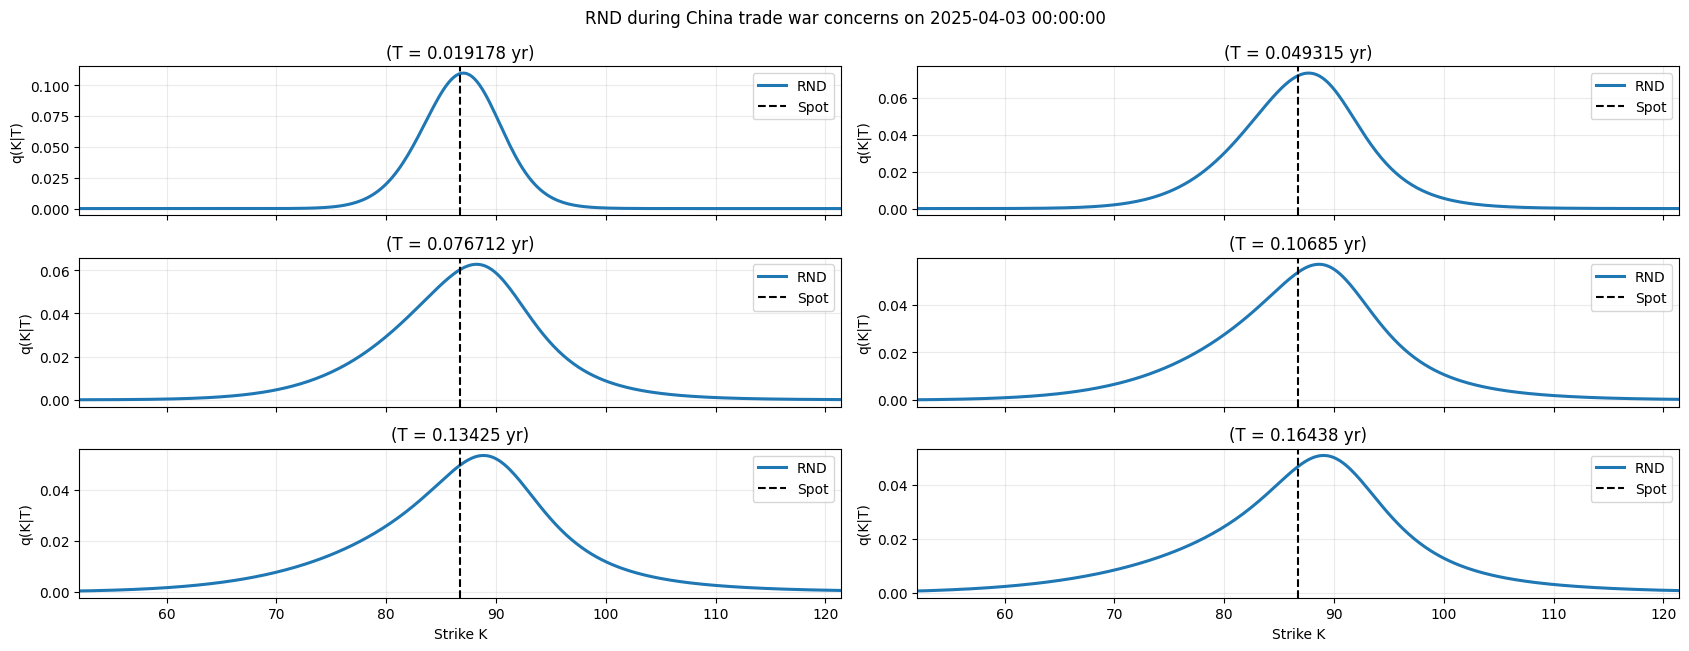

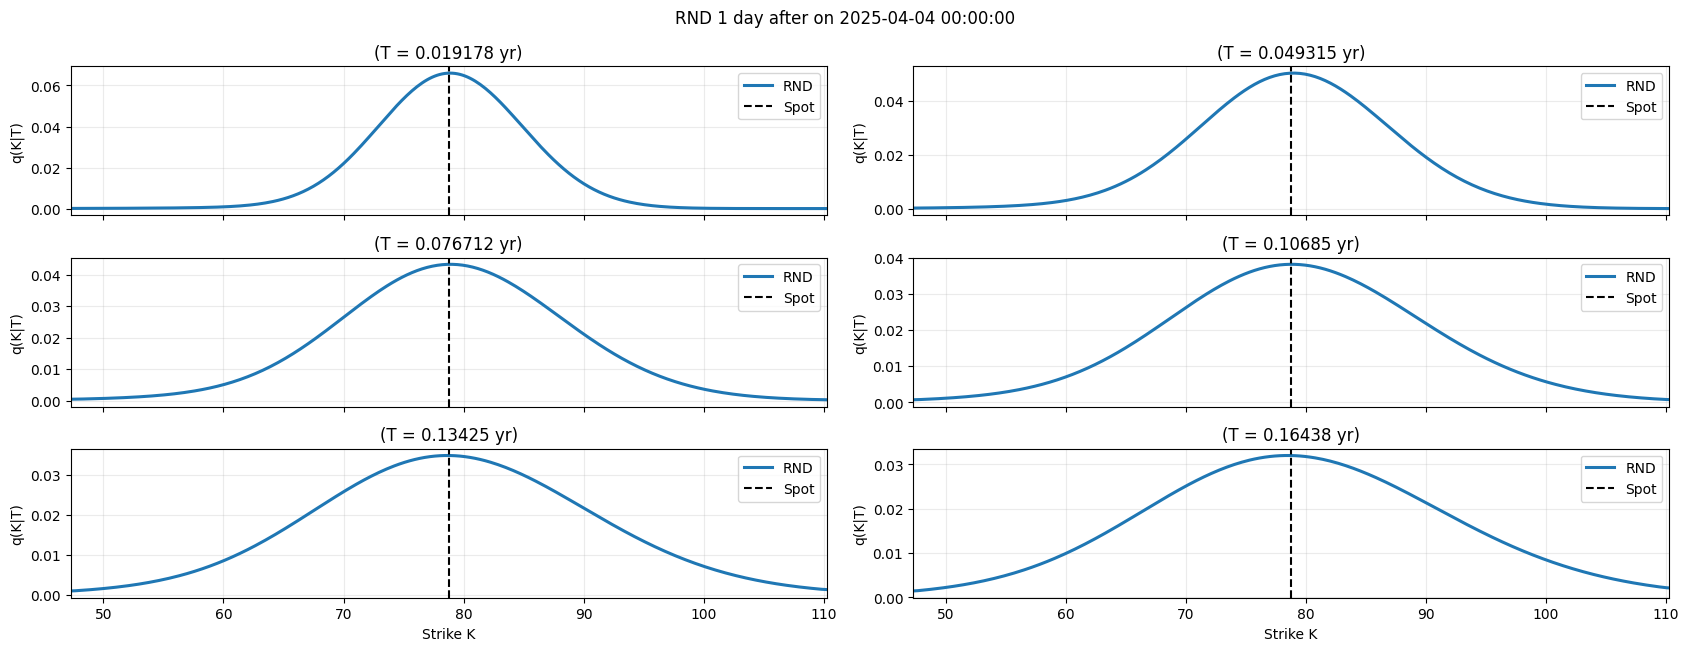

In [12]:
###Now we plot some figures## Lets compare 

#fig=panels.call_panels(result_dict[date_list[0]]["results"],day=result_dict[date_list[0]]["day"],n_panels=5,title=f"Observed vs fitted {date_list[0]}")
#fig=panels.call_panels(result_dict[date_list[1]]["results"],day=result_dict[date_list[1]]["day"],n_panels=5,title=f"Observed vs fitted {date_list[1]}")
#fig=panels.call_panels(result_dict[date_list[2]]["results"],day=result_dict[date_list[2]]["day"],n_panels=5,title=f"Observed vs fitted {date_list[2]}")
#fig=panels.call_panels(result_dict[date_list[3]]["results"],day=result_dict[date_list[3]]["day"],n_panels=5,title=f"Observed vs fitted {date_list[3]}")



fig=panels.rnd_panels(result_dict[date_list[0]]["results"], n_panels=6,panel_shape=(3,2), title=f"RND 2 days before crash on {date_list[0]}")
fig=panels.rnd_panels(result_dict[date_list[1]]["results"], n_panels=6,panel_shape=(3,2), title=f"RND 1 days before crash on {date_list[1]}")
fig=panels.rnd_panels(result_dict[date_list[2]]["results"], n_panels=6,panel_shape=(3,2), title=f"RND during China trade war concerns on {date_list[2]}")
fig=panels.rnd_panels(result_dict[date_list[3]]["results"], n_panels=6,panel_shape=(3,2), title=f"RND 1 day after on {date_list[3]}")

## The volatility Skew pre and post crash.
We can corroborate the changes in the risk neutral densities by looking at the implied volatility surface.


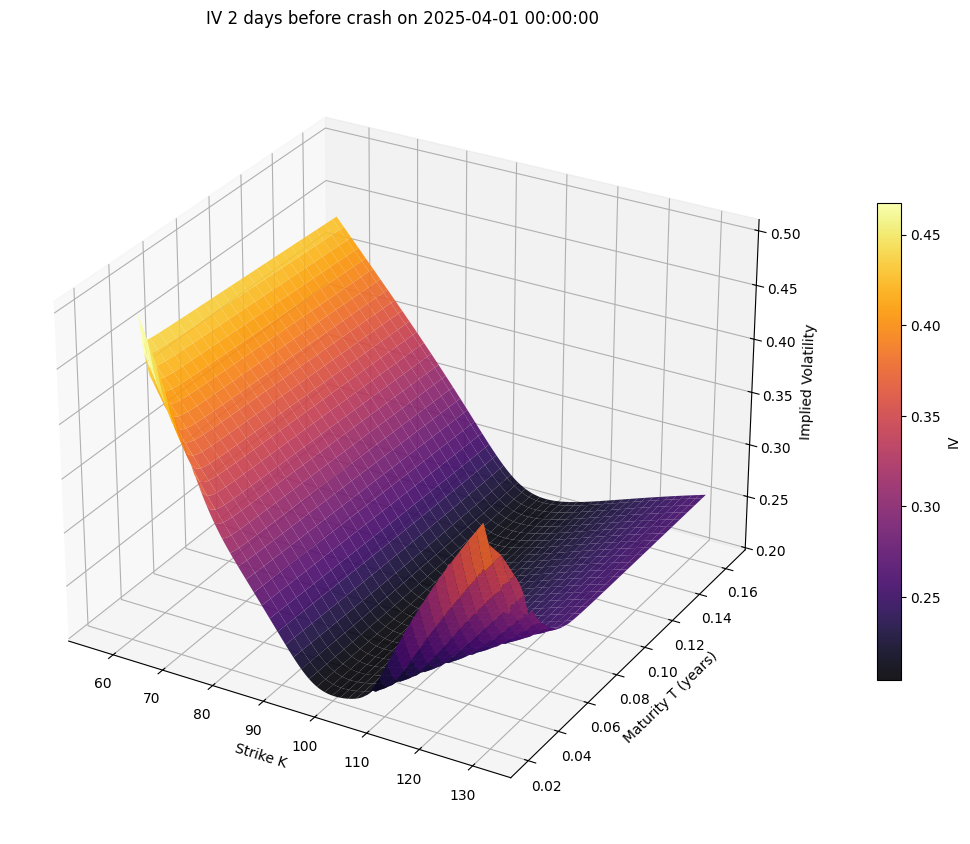

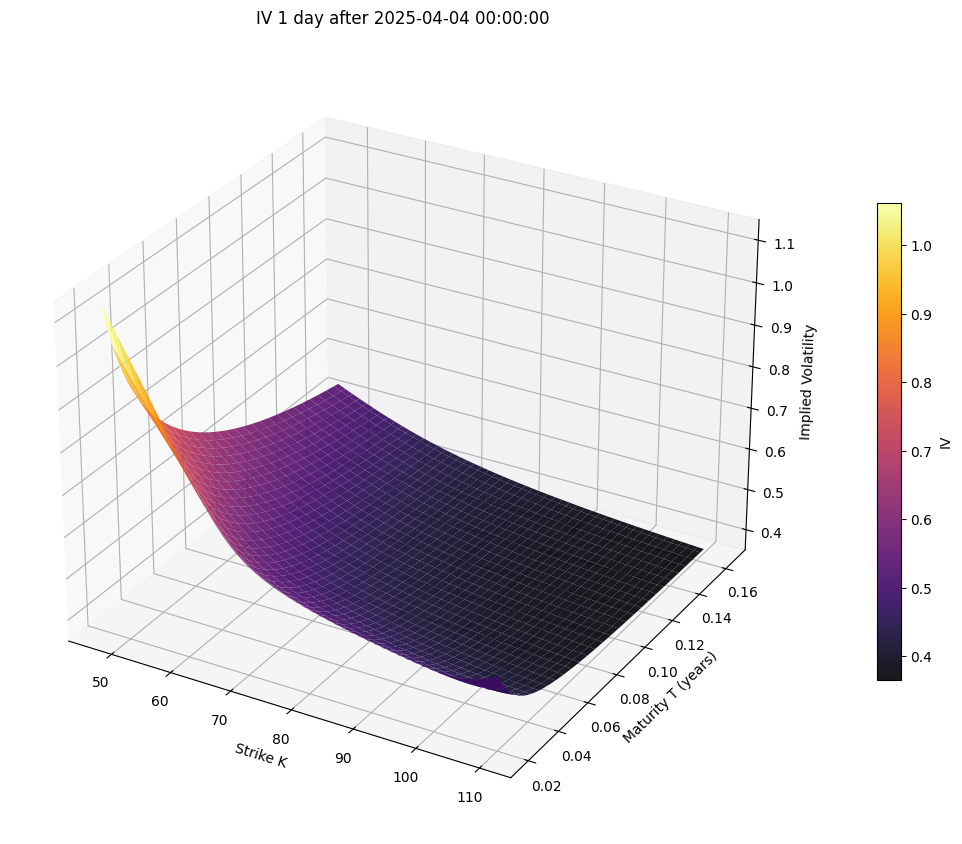

In [13]:
fig=surfaces.iv_surface_plot(result_dict[date_list[0]]["results"], title=f"IV 2 days before crash on {date_list[0]}",cmap="inferno",
interactive=False)
fig=surfaces.iv_surface_plot(result_dict[date_list[3]]["results"], title=f"IV 1 day after {date_list[3]}", cmap="inferno",
interactive=False)



## Volatility Skew Pre- and Post-Crash

Short-dated delta skew is essentially unchanged across the event window, while the compression is concentrated in medium- and longer-dated maturities. This pattern suggests that the crash primarily affected beliefs about the persistence and term structure of tail risk (and/or volatility risk premia), rather than the near-term distribution. Such a response is consistent with concerns that a potential trade war with China would exert longer-lasting effects on medium- to long-term energy prices rather than generating purely transitory short-run volatility.

The normalized delta skew is defined as:

$$
\text{Skew}(T,\Delta)
= \frac{\sigma_{\mathrm{call}}(T,\Delta) - \sigma_{\mathrm{put}}(T,|\Delta|)}
{\sigma_{\mathrm{ATM}}(T)}
$$



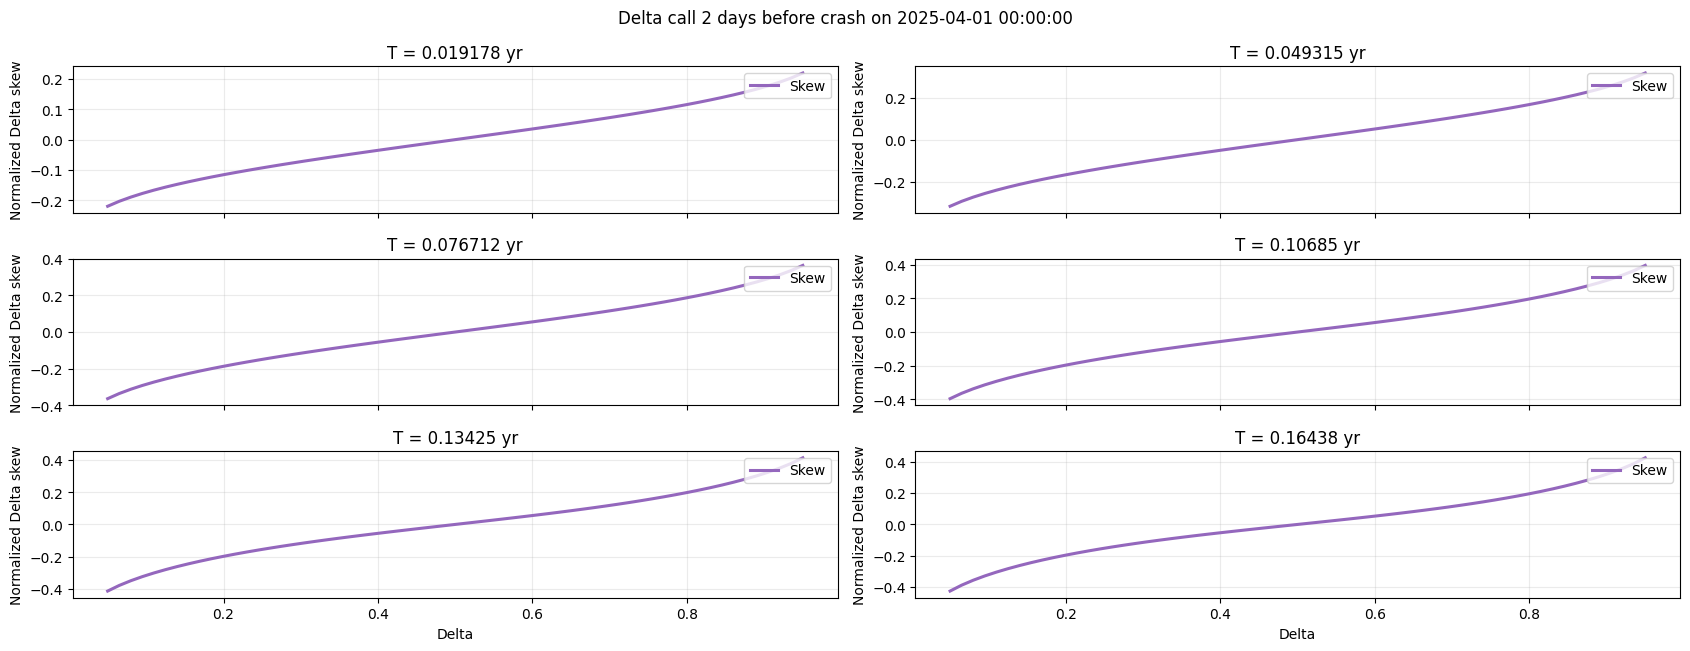

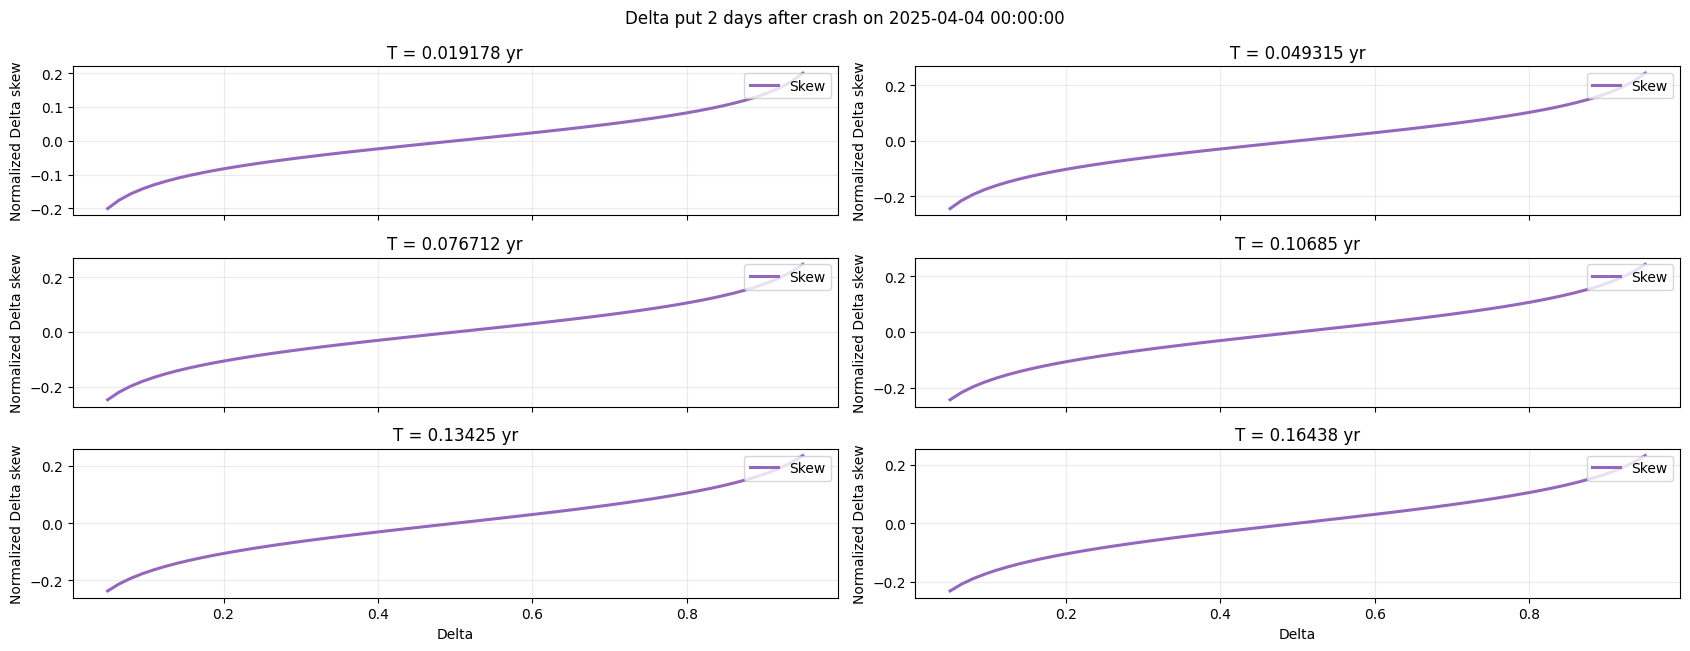

In [14]:
## The volatility Skew pre and post crash.
fig=panels.delta_panels(result_dict[date_list[0]]["results"], which="skew", n_panels=6,panel_shape=(3,2), title=f"Delta call 2 days before crash on {date_list[0]}")
fig=panels.delta_panels(result_dict[date_list[3]]["results"],which="skew", n_panels=6,panel_shape=(3,2), title=f"Delta put 2 days after crash on {date_list[3]}")
